
"""
# Lab: Agent Memory Management with LangGraph & Snowflake LLMs
## DAMG 7374 — Generative AI with LLMs

---

### Lab Objectives
By the end of this lab, you will understand:
1. Why memory matters in LLM agents
2. **Short-Term Memory** — in-thread, ephemeral (3 types)
3. **Long-Term Memory** — cross-thread, persistent (3 types)
4. **Cross-Thread Memory** — sharing context across sessions
5. How to wire all of this with **Snowflake Cortex LLMs**

### Memory Architecture Overview

```
┌───────────────────────────────────────────────────────────────┐
│                        AGENT MEMORY                           │
│                                                               │
│  ┌─────────────────────────┐  ┌─────────────────────────────┐ │
│  │    SHORT-TERM (Thread)  │  │   LONG-TERM (Cross-Thread)  │ │
│  │  ┌─────────────────┐    │  │  ┌───────────────────────┐  │ │
│  │  │ Full History    │    │  │  │ Semantic Memory       │  │ │
│  │  │ Sliding Window  │    │  │  │ Episodic Memory       │  │ │
│  │  │ Summarization   │    │  │  │ Procedural Memory     │  │ │
│  │  └─────────────────┘    │  │  └───────────────────────┘  │ │
│  │  Stored in: Checkpointer│  │  Stored in: Store           │ │
│  └─────────────────────────┘  └─────────────────────────────┘ │
└───────────────────────────────────────────────────────────────┘

In [16]:
 !pip install langgraph langchain langchain-core langchain-snowflake
 !pip install snowflake-snowpark-python snowflake-connector-python


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
pip install --upgrade langchain-snowflake


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:

import json
import uuid
from datetime import datetime
from typing import Annotated, Optional
from typing_extensions import TypedDict

# Jupyter display
from IPython.display import Image, display, Markdown

# LangChain core
from langchain_core.messages import (
    HumanMessage, AIMessage, SystemMessage, RemoveMessage, trim_messages,
)
from langchain_core.runnables import RunnableConfig

# LangGraph

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from typing import Annotated
from langgraph.prebuilt import InjectedStore

# Snowflake
from snowflake.snowpark import Session
from langchain_snowflake import ChatSnowflake          # langchain-snowflake >= 0.2.x

print("✅ All imports successful!")

✅ All imports successful!


In [19]:

# %%
# ─── Graph Visualization Helper ───────────────────────────────────────────────
def show_graph(graph, title: str = ""):
    """
    Render a compiled LangGraph as a Mermaid diagram (PNG) in Jupyter.
    Falls back to ASCII art if Mermaid rendering or internet is unavailable.

    Usage:
        show_graph(my_compiled_graph, title="My Agent Graph")
    """
    if title:
        display(Markdown(f"#### 📊 Graph: `{title}`"))
    try:
        # draw_mermaid_png() calls mermaid.ink — needs internet
        png_bytes = graph.get_graph().draw_mermaid_png()
        display(Image(png_bytes))
    except Exception as e:
        # ASCII fallback — always works, zero dependencies
        print(f"  [PNG unavailable: {e}]  → ASCII fallback:\n")
        print(graph.get_graph().draw_ascii())

print("✅ show_graph() ready")


✅ show_graph() ready



## ❄️ Section 1: Snowflake Connection

In [20]:

import os
from dotenv import load_dotenv

load_dotenv() 

True

In [21]:

connection_params = {
    "account":   os.getenv("SNOWFLAKE_ACCOUNT"),
    "user":      os.getenv("SNOWFLAKE_USER"),
    "password":  os.getenv("SNOWFLAKE_PASSWORD"),
    "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
    "database":  os.getenv("SNOWFLAKE_DATABASE"),
    "schema":    os.getenv("SNOWFLAKE_SCHEMA"),
    "role":      os.getenv("SNOWFLAKE_ROLE"),
}
session = Session.builder.configs(connection_params).create()

# ── Option B: Snowpark Notebook ───────────────────────────────────────────────
# from snowflake.snowpark.context import get_active_session
# session = get_active_session()

print(f"✅ Connected: {session.get_current_database()}.{session.get_current_schema()}")

# %%
llm = ChatSnowflake(
    model="llama4-maverick",       # try: mistral-large2, mistral-large, snowflake-arctic
    snowflake_session=session,     # passes existing Snowpark session — no extra credentials
    max_tokens=1024,
    temperature=0.3,
)
response = llm.invoke([HumanMessage("Say hello in one sentence.")])
print("LLM smoke test:", response.content)

Error in validate required environment variables: Missing required environment variable: SNOWFLAKE_PRIVATE_KEY_PATH
Error in key pair authentication attempt: Missing required environment variable: SNOWFLAKE_PRIVATE_KEY_PATH
Error in validate required environment variables: Missing required environment variable: SNOWFLAKE_PAT
Error in PAT authentication attempt: Missing required environment variable: SNOWFLAKE_PAT


✅ Connected: "LAB_DB_NEW"."LAB_SCHEMA_NEW"
LLM smoke test: Hello, it's nice to meet you!



---
## 🚫 Section 2: Agent WITHOUT Memory (Baseline)

The simplest possible agent — no checkpointer, no store.
Every invocation starts completely fresh. Zero recall between calls.

```
User ──▶ Agent ──▶ Response
                   (state discarded immediately after)
```

#### 📊 Graph: `Stateless Agent (No Memory)`

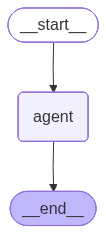

In [22]:

def stateless_agent(state: MessagesState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("agent", stateless_agent)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# ❌ No checkpointer — state dies after every invoke()
stateless_graph = builder.compile()

show_graph(stateless_graph, title="Stateless Agent (No Memory)")

In [23]:

print("TURN 1 — introduce ourselves")
r1 = stateless_graph.invoke({
    "messages": [HumanMessage("Hi! My name is Rithik and I'm a data engineer.")]
})
print("Agent:", r1["messages"][-1].content)

print("\nTURN 2 — agent has NO idea who we are")
r2 = stateless_graph.invoke({
    "messages": [HumanMessage("What's my name and what do I do?")]
})
print("Agent:", r2["messages"][-1].content)
print("""
🔴 PROBLEM: Agent forgot everything. Fix = add MEMORY.
""")

TURN 1 — introduce ourselves
Agent: Hello Rithik! Nice to meet you. What kind of data engineering work are you involved in? Are you working on building data pipelines, managing data warehouses, or something else?

TURN 2 — agent has NO idea who we are
Agent: You haven't told me your name or what you do, so I'm not aware of that information. I'm happy to chat with you and learn more about you, though! Would you like to share your name and occupation or something else about yourself?

🔴 PROBLEM: Agent forgot everything. Fix = add MEMORY.




---
## 🔵 Section 3: Short-Term Memory

Persists **within a single thread/session** via a **Checkpointer**.

```
Turn 1  ──saves──▶  Checkpoint(thread_1)
Turn 2  ──loads──▶  Checkpoint(thread_1) ──saves──▶  ...
```

| Type | What it stores | Best for |
|------|---------------|----------|
| **Full History** | Every message | Short sessions, debugging |
| **Sliding Window** | Last N tokens | Long chats, token control |
| **Summarization** | Summary + recent | Very long sessions |

---
### 3.1 — Full Message History

#### 📊 Graph: `Short-Term: Full History (MemorySaver)`

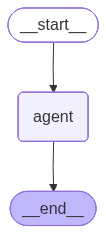

In [24]:

def chat_agent(state: MessagesState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("agent", chat_agent)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# ✅ MemorySaver keeps state in RAM, keyed by thread_id
memory_checkpointer = MemorySaver()
full_history_graph  = builder.compile(checkpointer=memory_checkpointer)

show_graph(full_history_graph, title="Short-Term: Full History (MemorySaver)")


In [25]:

# %%
# thread_id = unique conversation session key
config_s1 = {"configurable": {"thread_id": "session_rithik_001"}}

for msg in [
    "Hi! I'm Rithik, a data engineer working with Snowflake.",
    "What's my name and what do I work with?",
    "Summarize what you know about me so far.",
]:
    r = full_history_graph.invoke({"messages": [HumanMessage(msg)]}, config_s1)
    print(f"User : {msg}")
    print(f"Agent: {r['messages'][-1].content[:120]}...\n")

# %%
# Inspect checkpoint contents
snap = full_history_graph.get_state(config_s1)
msgs = snap.values["messages"]
print(f"📊 Messages in checkpoint: {len(msgs)}")
for m in msgs:
    role = "👤 Human" if isinstance(m, HumanMessage) else "🤖 AI"
    print(f"  {role}: {m.content[:80]}...")

User : Hi! I'm Rithik, a data engineer working with Snowflake.
Agent: Hi Rithik! Nice to meet you. Snowflake is a great platform to work with. What kind of projects are you working on as a d...

User : What's my name and what do I work with?
Agent: Your name is Rithik, and you work with Snowflake as a data engineer....

User : Summarize what you know about me so far.
Agent: Here's a summary of what I know about you so far:

* Your name is Rithik.
* You work as a data engineer.
* You work with...

📊 Messages in checkpoint: 6
  👤 Human: Hi! I'm Rithik, a data engineer working with Snowflake....
  🤖 AI: Hi Rithik! Nice to meet you. Snowflake is a great platform to work with. What ki...
  👤 Human: What's my name and what do I work with?...
  🤖 AI: Your name is Rithik, and you work with Snowflake as a data engineer....
  👤 Human: Summarize what you know about me so far....
  🤖 AI: Here's a summary of what I know about you so far:

* Your name is Rithik.
* You ...


In [26]:

# %%
# Different thread → fully isolated memory
config_s2 = {"configurable": {"thread_id": "session_priya_002"}}
r = full_history_graph.invoke({"messages": [HumanMessage("What's my name?")]}, config_s2)
print("Different thread — Agent:", r["messages"][-1].content)
print("\n✅ Threads are isolated. session_arjun_001 ≠ session_priya_002")

Different thread — Agent: You haven't told me your name. This is the start of our conversation. What's your name?

✅ Threads are isolated. session_arjun_001 ≠ session_priya_002



---
### 3.2 — Sliding Window Memory (Token Trimming)

**Problem:** Full history grows unboundedly → 🪙 token costs explode.  
**Solution:** Keep only the **last K tokens**.

```
[msg1, msg2, msg3, msg4, msg5]
             ↑ trim here (based on token budget)
  keep ────────────────▶ [msg4, msg5]
```

#### 📊 Graph: `Short-Term: Sliding Window (trim_messages)`

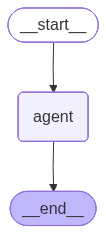

In [27]:

WINDOW_MAX_TOKENS = 800

def windowed_agent(state: MessagesState) -> dict:
    trimmed = trim_messages(
        state["messages"],
        max_tokens=WINDOW_MAX_TOKENS,
        strategy="last",          # keep MOST RECENT messages
        token_counter=llm,        # use LLM's own tokenizer
        include_system=True,
        allow_partial=False,
    )
    print(f"  [Window] {len(trimmed)}/{len(state['messages'])} msgs used")
    return {"messages": [llm.invoke(trimmed)]}

builder_w = StateGraph(MessagesState)
builder_w.add_node("agent", windowed_agent)
builder_w.add_edge(START, "agent")
builder_w.add_edge("agent", END)

windowed_graph = builder_w.compile(checkpointer=MemorySaver())

show_graph(windowed_graph, title="Short-Term: Sliding Window (trim_messages)")


In [ ]:

# %%
config_w = {"configurable": {"thread_id": "window_demo"}}
for msg in [
    "My name is Priya and I'm studying ML engineering.",
    "I love working on NLP projects, especially summarization.",
    "My favorite framework is PyTorch.",
    "I once built a sentiment analysis pipeline for 10M tweets.",
    "I also know TensorFlow and JAX.",
    "What are my top interests and skills based on our conversation?",
]:
    print(f"\n\033[92mHuman: {msg}\033[0m")
    r = windowed_graph.invoke({"messages": [HumanMessage(msg)]}, config_w)
    print(f"\033[94mAgent: {r['messages'][-1].content[:]}\033[0m...")



Human: My name is Priya and I'm studying ML engineering.
  [Window] 1/1 msgs used
Agent: Nice to meet you, Priya! What area of ML engineering are you most interested in? Are you working on any projects or looking to explore specific topics? I'm here to help....

Human: I love working on NLP projects, especially summarization.
  [Window] 3/3 msgs used
Agent: Text summarization is a fascinating area of NLP. It's a challenging task, but can be really useful in many applications, such as news aggregation, document summarization, and more.

What kind of summarization are you interested in? Are you looking into extractive summarization (selecting key sentences from the original text) or abstractive summarization (generating a summary that's not necessarily a direct copy of the original text)? Or perhaps you're exploring other related areas like multi-document summarization?

Also, have you worked with any specific NLP libraries or frameworks, such as NLTK, spaCy, or Transformers?...

Human:


---
### 3.3 — Conversation Summarization Memory

**Problem:** Sliding window drops old messages entirely.  
**Solution:** Periodically **compress** old messages into a running summary.

```
[msg1 … msg8]  →  summarize  →  summary_str  +  [msg7, msg8]
  (old, compressed)                               (recent, kept)
```

Graph flow:
```
START ──▶ agent ──▶ should_summarize? ──YES──▶ summarize ──▶ END
                         │
                        NO
                         ▼
                        END
```

#### 📊 Graph: `Short-Term: Summarization Memory`

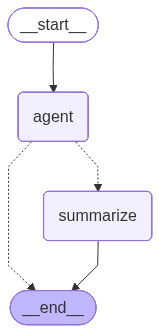

In [29]:

class SummaryState(TypedDict):
    messages: Annotated[list, add_messages]
    summary:  str                             # running summary of old turns

SUMMARIZE_AFTER = 6   # compress when message count exceeds this

# %%
def summarize_node(state: SummaryState) -> dict:
    summary  = state.get("summary", "")
    messages = state["messages"]

    prior        = f"Existing summary:\n{summary}\n\n" if summary else ""
    history_text = "\n".join(
        f"{'User' if isinstance(m, HumanMessage) else 'AI'}: {m.content}"
        for m in messages[:-2]
    )
    prompt      = HumanMessage(
        f"{prior}Summarize the following conversation in 3-4 bullet points:\n\n{history_text}"
    )
    new_summary = llm.invoke([prompt]).content
    print(f"\n  📝 Compressed {len(messages)-2} msgs → summary")
    print(f"  Preview: {new_summary[:120]}...\n")

    to_delete = [RemoveMessage(id=m.id) for m in messages[:-2]]
    return {"summary": new_summary, "messages": to_delete}


def summary_agent_node(state: SummaryState) -> dict:
    summary  = state.get("summary", "")
    messages = state["messages"]
    if summary:
        messages = [SystemMessage(f"Prior conversation summary:\n{summary}")] + messages
    return {"messages": [llm.invoke(messages)]}


def should_summarize(state: SummaryState) -> str:
    return "summarize" if len(state["messages"]) > SUMMARIZE_AFTER else END

# %%
builder_s = StateGraph(SummaryState)
builder_s.add_node("agent",     summary_agent_node)
builder_s.add_node("summarize", summarize_node)
builder_s.add_edge(START, "agent")
builder_s.add_conditional_edges(
    "agent",
    should_summarize,
    {"summarize": "summarize", END: END}
)
builder_s.add_edge("summarize", END)

summary_graph = builder_s.compile(checkpointer=MemorySaver())

show_graph(summary_graph, title="Short-Term: Summarization Memory")

In [30]:

config_s = {"configurable": {"thread_id": "summary_demo"}}
for i, msg in enumerate([
    "Hi, I'm Rohan, a cloud architect at a fintech company.",
    "We use AWS and Snowflake for our data platform.",
    "I'm working on a real-time fraud detection pipeline.",
    "The pipeline processes 50k transactions per second.",
    "We use Kafka for streaming and Flink for stateful ops.",
    "We recently integrated LLMs for anomaly explanation.",
    "What have we talked about so far?",    # ← triggers summarization
    "What was my core tech stack again?",
], 1):
    snap   = summary_graph.get_state(config_s).values
    n_msgs = len(snap.get("messages", []))
    print(f"Turn {i} (msgs in state: {n_msgs}): {msg}")
    r = summary_graph.invoke({"messages": [HumanMessage(msg)]}, config_s)
    print(f"\033[94mAgent: {r['messages'][-1].content[:]}\033[0m...\n")


Turn 1 (msgs in state: 0): Hi, I'm Rohan, a cloud architect at a fintech company.
Agent: Nice to meet you, Rohan! What kind of cloud architecture are you working on for your fintech company? Are you dealing with sensitive financial data and compliance requirements?...

Turn 2 (msgs in state: 2): We use AWS and Snowflake for our data platform.
Agent: That's a great stack! AWS provides a robust infrastructure, and Snowflake is a powerful cloud-based data warehousing solution. What specific challenges or projects are you currently working on with your data platform? Are you optimizing for performance, cost, or security?...

Turn 3 (msgs in state: 4): I'm working on a real-time fraud detection pipeline.
Agent: Real-time fraud detection is a critical application, especially in fintech. That's a challenging but interesting project. Are you using any machine learning (ML) models to identify potential fraudulent transactions, or is it more of a rules-based approach? And how are you handling th


---
## 🟢 Section 4: Long-Term Memory

Persists **across threads and sessions** via a **Store** (outside the checkpointer).

```
Thread A ──writes──▶  Store["user:arjun"]["facts"]
Thread B ──reads───▶  Store["user:arjun"]["facts"]
Thread C ──reads───▶  Store["user:arjun"]["facts"]
```

| Type | Stores | Example |
|------|--------|---------|
| **Semantic** | Facts / knowledge | "User prefers Python" |
| **Episodic** | Past events | "Last session: fixed Cortex Search" |
| **Procedural** | Rules / behavior | "Always use bullet points" |

In [31]:

long_term_store = InMemoryStore()
print("InMemoryStore initialized ✅")

InMemoryStore initialized ✅



---
### 4.1 — Semantic Memory

Stores **facts** about the user. The agent:
1. **Reads** saved facts → personalizes the response
2. **Writes** new facts learned in this turn → persists for future sessions

Graph flow:
```
START ──▶ agent (load facts → reply → extract & save new facts) ──▶ END
```

In [32]:
FACT_EXTRACTION_PROMPT = """You are a memory extraction assistant.
Given a user message, extract any personal facts worth remembering.
Return ONLY a valid JSON array of strings. No markdown. Empty array if nothing notable.

Examples:
  Input : "I'm a data scientist at Google working on NLP"
  Output: ["Works as data scientist at Google", "Specializes in NLP"]
  Input : "What's the weather like?"
  Output: []
"""

In [33]:

def extract_facts(user_message: str) -> list:
    resp = llm.invoke([SystemMessage(FACT_EXTRACTION_PROMPT), HumanMessage(user_message)])
    try:
        facts = json.loads(resp.content.strip())
        return facts if isinstance(facts, list) else []
    except json.JSONDecodeError:
        return []

#### 📊 Graph: `Long-Term: Episodic Memory`

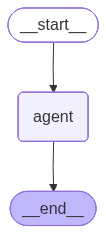

In [ ]:


def extract_facts(user_message: str) -> list:
    resp = llm.invoke([SystemMessage(FACT_EXTRACTION_PROMPT), HumanMessage(user_message)])
    try:
        facts = json.loads(resp.content.strip())
        return facts if isinstance(facts, list) else []
    except json.JSONDecodeError:
        return []

# %%
def semantic_agent(state: MessagesState, config: RunnableConfig) -> dict:
    store     = long_term_store                                  # captured via closure
    user_id   = config["configurable"].get("user_id", "anonymous")
    namespace = ("memory", user_id, "semantic")

    # 1. Load existing facts
    existing   = store.search(namespace)
    facts_text = ""
    if existing:
        facts_text = "\n".join(f"  • {i.value['fact']}" for i in existing)
        print(f"  [Semantic] Loaded {len(existing)} facts for '{user_id}'")

    # 2. Build context-enriched prompt
    sys_content = "You are a helpful assistant."
    if facts_text:
        sys_content += f"\n\nWhat you know about this user:\n{facts_text}"
    response = llm.invoke([SystemMessage(sys_content)] + state["messages"])

    # 3. Extract & save new facts
    last_human = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None
    )
    if last_human:
        for fact in extract_facts(last_human):
            store.put(namespace, f"fact_{uuid.uuid4().hex[:8]}",
                      {"fact": fact, "ts": str(datetime.now())})
            print(f"  [Semantic] Saved: {fact}")

    return {"messages": [response]}

# %%
builder_sem = StateGraph(MessagesState)
builder_sem.add_node("agent", semantic_agent)
builder_sem.add_edge(START, "agent")
builder_sem.add_edge("agent", END)

semantic_graph = builder_sem.compile(checkpointer=MemorySaver())

show_graph(semantic_graph, title="Long-Term: Semantic Memory")

In [ ]:

# Session 1 — introduce the user
config_sem1 = {"configurable": {"thread_id": "sem_s1", "user_id": "arjun"}}
for msg in [
    "Hi, I'm Arjun. I'm a senior data engineer specializing in Snowflake and dbt.",
    "I'm currently building a real-time analytics pipeline for an e-commerce client.",
]:
    r = semantic_graph.invoke({"messages": [HumanMessage(msg)]}, config_sem1)
    print(f"User : {msg}")
    print(f"Agent: {r['messages'][-1].content[:120]}...\n")


In [42]:

# Session 2 — NEW thread, SAME user_id → facts survive!
config_sem2 = {"configurable": {"thread_id": "sem_s2_new", "user_id": "arjun"}}
r = semantic_graph.invoke(
    {"messages": [HumanMessage("Can you remind me what you know about me?")]}, config_sem2
)
print("Agent:", r["messages"][-1].content)

# %%
print("\n📦 Facts in store for 'arjun':")
for item in long_term_store.search(("memory", "arjun", "semantic")):
    print(f"  • [{item.key}] {item.value['fact']}")


  [Semantic] Loaded 6 facts for 'arjun'
Agent: You are Arjun, a senior data engineer who specializes in Snowflake and dbt. You're currently working on building a real-time analytics pipeline for an e-commerce client. That's the gist of it! Is there anything specific you'd like to discuss or any way I can assist you with your project?

📦 Facts in store for 'arjun':
  • [fact_bc6ede30] Name is Arjun
  • [fact_d6edf80c] Works as senior data engineer
  • [fact_8e61770e] Specializes in Snowflake
  • [fact_db1db5f7] Specializes in dbt
  • [fact_fb5d824a] Building real-time analytics pipeline
  • [fact_01d4b852] Working with e-commerce client



### 4.2 — Episodic Memory

Records **specific past events** — what happened, when, and what the outcome was.

```
Session ends  →  compress  →  1-line episode entry  →  saved in Store
Next session  →  load episodes  →  injected as context

In [43]:

EPISODE_SUMMARY_PROMPT = """You are a memory logging assistant.
Summarize the following conversation as a single-line episode entry.
Format: "<timestamp> — <1-sentence summary>"
Return ONLY the formatted line, nothing else."""

#### 📊 Graph: `Long-Term: Episodic Memory`

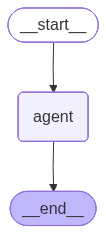

In [51]:


def save_episode(session_id, messages, store, user_id):
    convo = "\n".join(
        f"{'User' if isinstance(m, HumanMessage) else 'AI'}: {m.content}"
        for m in messages
    )
    summary = llm.invoke([SystemMessage(EPISODE_SUMMARY_PROMPT), HumanMessage(convo)]).content.strip()
    ep = {"session_id": session_id, "summary": summary,
          "timestamp": str(datetime.now()), "turns": len(messages)}
    store.put(("memory", user_id, "episodic"), session_id, ep)
    print(f"  [Episodic] Saved: {summary[:80]}...")
    return ep

def episodic_agent(state: MessagesState, config: RunnableConfig) -> dict:
    store      = episodic_store                                  # captured via closure
    user_id    = config["configurable"].get("user_id", "anonymous")
    session_id = config["configurable"].get("thread_id", "unknown")
    namespace  = ("memory", user_id, "episodic")

    past = store.search(namespace)
    ep_ctx = ""
    if past:
        lines  = [f"  • {e.value['summary']}" for e in past[-5:]]
        ep_ctx = "\nYour past sessions with this user:\n" + "\n".join(lines)
        print(f"  [Episodic] {len(past)} past episode(s) loaded")

    messages = [SystemMessage(f"You are a helpful assistant.{ep_ctx}")] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

# %%
episodic_store = InMemoryStore()

builder_ep = StateGraph(MessagesState)
builder_ep.add_node("agent", episodic_agent)
builder_ep.add_edge(START, "agent")
builder_ep.add_edge("agent", END)

episodic_graph = episodic_graph = builder_ep.compile(checkpointer=MemorySaver())

show_graph(episodic_graph, title="Long-Term: Episodic Memory")

# %%
cfg_ep1 = {"configurable": {"thread_id": "ep_s1", "user_id": "priya"}}
for msg in [
    "I'm struggling with Cortex Search not returning results.",
    "The issue is that CHANGE_TRACKING wasn't enabled on my table.",
    "Got it, ALTER TABLE ... SET CHANGE_TRACKING = TRUE fixed it!",
    "Thanks, the service is now working perfectly.",
]:
    episodic_graph.invoke({"messages": [HumanMessage(msg)]}, cfg_ep1)

In [ ]:

cfg_ep1 = {"configurable": {"thread_id": "ep_s1", "user_id": "priya"}}
for msg in [
    "I'm struggling with Cortex Search not returning results.",
    "The issue is that CHANGE_TRACKING wasn't enabled on my table.",
    "Got it, ALTER TABLE ... SET CHANGE_TRACKING = TRUE fixed it!",
    "Thanks, the service is now working perfectly.",
]:
    episodic_graph.invoke({"messages": [HumanMessage(msg)]}, cfg_ep1)

In [52]:

# ── Explicitly save the episode after Session 1 ends ─────────────────────────
session1_messages = episodic_graph.get_state(cfg_ep1).values["messages"]
save_episode("ep_s1", session1_messages, episodic_store, "priya")
print("✅ Session 1 episode saved")


  [Episodic] Saved: 2023-03-09 14:30:00 — User resolved issue with Cortex Search not returning resul...
✅ Session 1 episode saved


In [53]:

# Session 2 — agent recalls what happened in Session 1
cfg_ep2 = {"configurable": {"thread_id": "ep_s2_new", "user_id": "priya"}}
r = episodic_graph.invoke(
    {"messages": [HumanMessage("I'm having Snowflake issues again. What did we fix last time?")]},
    cfg_ep2
)
print("Agent:", r["messages"][-1].content)

  [Episodic] 1 past episode(s) loaded
Agent: You were having issues with Cortex Search not returning results. We resolved the issue by enabling CHANGE_TRACKING on your table using the correct SQL syntax.



---
### 4.3 — Procedural Memory

Stores **HOW the agent should behave** for this user.

```
User: "Please be more concise"
  → LLM detects preference change
  → Rule saved: "Keep answers under 3 sentences"
  → Applied in ALL future sessions for this user
```

In [54]:

DEFAULT_PROCEDURES = [
    "Be concise and technical — avoid beginner-level explanations.",
    "Use code examples when explaining technical concepts.",
    "Always mention Snowflake-specific alternatives when relevant.",
]

In [55]:

PROCEDURE_UPDATE_PROMPT = """Analyze the user message for explicit behavior preferences.
If found, return: {"update": true, "rule": "<new rule>"}
Otherwise return: {"update": false}
Return ONLY valid JSON."""


#### 📊 Graph: `Long-Term: Procedural Memory`

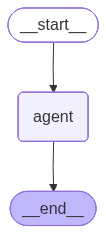

In [56]:

def procedural_agent(state: MessagesState, config: RunnableConfig) -> dict:
    store     = proc_store                                       # captured via closure
    user_id   = config["configurable"].get("user_id", "anonymous")
    namespace = ("memory", user_id, "procedural")

    saved = store.search(namespace)
    rules = DEFAULT_PROCEDURES + [i.value["rule"] for i in saved]
    print(f"  [Procedural] {len(rules)} active rules")

    sys_content = "You are a helpful assistant. Follow these rules:\n" + \
                  "\n".join(f"  {i+1}. {r}" for i, r in enumerate(rules))
    response = llm.invoke([SystemMessage(sys_content)] + state["messages"])

    # Detect & save user preference changes
    last_human = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None
    )
    if last_human:
        try:
            chk = llm.invoke([SystemMessage(PROCEDURE_UPDATE_PROMPT), HumanMessage(last_human)])
            res = json.loads(chk.content.strip())
            if res.get("update"):
                store.put(namespace, f"rule_{uuid.uuid4().hex[:8]}",
                          {"rule": res["rule"], "ts": str(datetime.now())})
                print(f"  [Procedural] New rule: {res['rule']}")
        except Exception:
            pass

    return {"messages": [response]}

# %%
proc_store = InMemoryStore()

builder_pr = StateGraph(MessagesState)
builder_pr.add_node("agent", procedural_agent)
builder_pr.add_edge(START, "agent")
builder_pr.add_edge("agent", END)

procedural_graph = builder_pr.compile(checkpointer=MemorySaver())

show_graph(procedural_graph, title="Long-Term: Procedural Memory")

In [57]:

cfg_pr1 = {"configurable": {"thread_id": "proc_s1", "user_id": "rohan"}}
r1 = procedural_graph.invoke(
    {"messages": [HumanMessage("Explain what a vector database is.")]}, cfg_pr1
)
print("Agent (default style):", r1["messages"][-1].content[:200], "\n...")

  [Procedural] 3 active rules
Agent (default style): **Vector Database Overview**

A vector database is a type of database designed to efficiently store, index, and query large datasets of dense vectors, typically generated by 
...


In [58]:

r2 = procedural_graph.invoke(
    {"messages": [HumanMessage("Please always respond in simple plain English, no jargon.")]}, cfg_pr1
)
print("\nAgent:", r2["messages"][-1].content)

  [Procedural] 3 active rules

Agent: **What is a Vector Database?**
A vector database is a special kind of database that helps you store and search for similar things, like images or text, by comparing their numerical representations.

**How Does it Work?**
The database stores numbers that represent objects, like pictures or words. When you want to find something similar, it compares the numbers to find the closest matches.

**What is it Used For?**
It's used for things like:

*   Finding similar images or text
*   Recommending products or content
*   Detecting duplicates

**Snowflake Alternative**
Snowflake is a database that can be used for some of these tasks, but it's not specifically designed for vector search. For very large datasets, a specialized vector database might be a better choice.

**Example: Image Search**
Imagine you have a collection of images and you want to find images that are similar to a specific picture. A vector database can help you do that by comparing the n

In [59]:

# New session — rule persists
cfg_pr2 = {"configurable": {"thread_id": "proc_s2_new", "user_id": "rohan"}}
r3 = procedural_graph.invoke(
    {"messages": [HumanMessage("Explain what embeddings are.")]}, cfg_pr2
)
print("\nNew session (rule applied):", r3["messages"][-1].content[:200], "...")

  [Procedural] 3 active rules

New session (rule applied): **Embeddings: A Vector Representation of Data**

Embeddings are a fundamental concept in machine learning and natural language processing (NLP). They represent complex data, such as words, phrases, or ...



---
## 🔁 Section 5: Cross-Thread Memory

All long-term types support **cross-thread recall** because they live in the
**Store** (not the checkpointer). Same `user_id` → same namespace → shared memory.

Graph: all three memory types wired into a single unified agent.

```
Store["memory/sam/semantic"]   ──┐
Store["memory/sam/episodic"]   ──┼──▶  agent  ──▶  personalized reply
Store["memory/sam/procedural"] ──┘
```

#### 📊 Graph: `Cross-Thread: Unified Memory Agent`

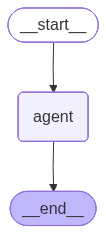

In [60]:

# %%
unified_store = InMemoryStore()

def unified_memory_agent(state: MessagesState, config: RunnableConfig) -> dict:
    store = unified_store                                        # captured via closure
    uid   = config["configurable"].get("user_id", "guest")

    sem_items  = store.search(("memory", uid, "semantic"))
    ep_items   = store.search(("memory", uid, "episodic"))
    proc_items = store.search(("memory", uid, "procedural"))

    parts = ["You are a personalized AI assistant."]
    if sem_items:
        parts.append("\n### Known Facts About User")
        parts += [f"  • {i.value['fact']}" for i in sem_items]
    if ep_items:
        parts.append("\n### Past Session History")
        parts += [f"  • {i.value['summary']}" for i in ep_items[-3:]]
    if proc_items:
        parts.append("\n### Behavioral Rules")
        parts += [f"  • {i.value['rule']}" for i in proc_items]

    return {"messages": [llm.invoke([SystemMessage("\n".join(parts))] + state["messages"])]}

# %%
builder_uni = StateGraph(MessagesState)
builder_uni.add_node("agent", unified_memory_agent)
builder_uni.add_edge(START, "agent")
builder_uni.add_edge("agent", END)

unified_graph = builder_uni.compile(checkpointer=MemorySaver())

show_graph(unified_graph, title="Cross-Thread: Unified Memory Agent")

In [61]:

# %%
# Pre-populate store with facts and rules for "sam"
unified_store.put(("memory","sam","semantic"),   "f1", {"fact":"Sam is a ML engineer at Amazon"})
unified_store.put(("memory","sam","semantic"),   "f2", {"fact":"Sam knows PyTorch and JAX"})
unified_store.put(("memory","sam","episodic"),   "e1", {"summary":"Sam asked about LangGraph agent patterns"})
unified_store.put(("memory","sam","procedural"), "r1", {"rule":"Sam prefers concise bullet-point answers"})

print("✅ Store pre-populated for user 'sam'")

✅ Store pre-populated for user 'sam'


In [62]:

# %%
cfgA = {"configurable": {"thread_id": "thread_A_monday", "user_id": "sam"}}
rA   = unified_graph.invoke({"messages": [HumanMessage("Hey! What do you know about me?")]}, cfgA)
print("Thread A:\n", rA["messages"][-1].content)

Thread A:
 * You're Sam, a ML engineer at Amazon
* You're familiar with PyTorch and JAX
* You previously asked about LangGraph agent patterns


In [63]:

cfgB = {"configurable": {"thread_id": "thread_B_friday", "user_id": "sam"}}
rB   = unified_graph.invoke(
    {"messages": [HumanMessage("Recommend a project idea that fits my skills.")]}, cfgB
)
print("\nThread B (different day):\n", rB["messages"][-1].content)


Thread B (different day):
 * Implement a PyTorch or JAX model using LangGraph agent patterns for a task like text classification or reinforcement learning. 
* Potential applications include: 
  + Sentiment analysis
  + Dialogue generation
  + Game playing AI 
* You can leverage Amazon-specific datasets or services, like Amazon Reviews or SageMaker, to enhance the project.



---
## ❄️ Section 6: Snowflake-Backed Long-Term Memory (Production)

`InMemoryStore` dies when the process ends.
In production, back the store with a **Snowflake table**.

```
                    ┌────────────────────────────────┐
  Agent Node  ─────▶│  SnowflakeMemoryStore          │
                    │  • Reads from AGENT_MEMORY      │
                    │  • Writes using MERGE INTO      │
                    │  • VARIANT column for JSON      │
                    └──────────────┬─────────────────┘
                                   │
                    ┌──────────────▼──────────────────┐
                    │        AGENT_MEMORY table        │
                    │  NAMESPACE | KEY | VALUE(VARIANT)│
                    └──────────────────────────────────┘
```

In [64]:

# ── Step 1: Create the backing table ─────────────────────────────────────────
session.sql("""
    CREATE TABLE IF NOT EXISTS AGENT_MEMORY (
        NAMESPACE   VARCHAR(500)   NOT NULL,
        KEY         VARCHAR(200)   NOT NULL,
        VALUE       VARIANT        NOT NULL,
        CREATED_AT  TIMESTAMP_NTZ  DEFAULT CURRENT_TIMESTAMP(),
        UPDATED_AT  TIMESTAMP_NTZ  DEFAULT CURRENT_TIMESTAMP(),
        PRIMARY KEY (NAMESPACE, KEY)
    )
""").collect()
print("✅ AGENT_MEMORY table ready")

✅ AGENT_MEMORY table ready


In [65]:

# ── Step 2: SnowflakeMemoryStore ──────────────────────────────────────────────
class SnowflakeMemoryStore:
    """Snowflake-backed persistent key-value store. Mirrors InMemoryStore interface."""

    def __init__(self, sf_session: Session, table: str = "AGENT_MEMORY"):
        self.session = sf_session
        self.table   = table

    @staticmethod
    def _ns_str(namespace: tuple) -> str:
        return "/".join(namespace)

    def _safe_json(self, obj) -> str:
        return json.dumps(obj).replace("'", "\\'")

    def put(self, namespace: tuple, key: str, value: dict) -> None:
        ns  = self._ns_str(namespace)
        val = self._safe_json(value)
        self.session.sql(f"""
            MERGE INTO {self.table} t
            USING (SELECT '{ns}' AS NS, '{key}' AS K, PARSE_JSON($${val}$$) AS V) s
            ON t.NAMESPACE = s.NS AND t.KEY = s.K
            WHEN MATCHED     THEN UPDATE SET VALUE = s.V, UPDATED_AT = CURRENT_TIMESTAMP()
            WHEN NOT MATCHED THEN INSERT (NAMESPACE, KEY, VALUE) VALUES (s.NS, s.K, s.V)
        """).collect()

    def get(self, namespace: tuple, key: str) -> Optional[dict]:
        ns   = self._ns_str(namespace)
        rows = self.session.sql(f"""
            SELECT VALUE::VARCHAR AS V FROM {self.table}
            WHERE NAMESPACE = '{ns}' AND KEY = '{key}'
        """).collect()
        return json.loads(rows[0]["V"]) if rows else None

    def search(self, namespace_prefix: tuple, limit: int = 50) -> list:
        ns_prefix = self._ns_str(namespace_prefix)
        rows = self.session.sql(f"""
            SELECT KEY, VALUE::VARCHAR AS V FROM {self.table}
            WHERE  NAMESPACE LIKE '{ns_prefix}%'
            ORDER  BY UPDATED_AT DESC LIMIT {limit}
        """).collect()
        return [{"key": r["KEY"], "value": json.loads(r["V"])} for r in rows]

    def delete(self, namespace: tuple, key: str) -> None:
        ns = self._ns_str(namespace)
        self.session.sql(f"""
            DELETE FROM {self.table} WHERE NAMESPACE='{ns}' AND KEY='{key}'
        """).collect()

    def show(self, user_id: str) -> None:
        rows = self.session.sql(f"""
            SELECT NAMESPACE, KEY, VALUE::VARCHAR AS V, UPDATED_AT
            FROM   {self.table}
            WHERE  NAMESPACE LIKE '%{user_id}%'
            ORDER  BY NAMESPACE, UPDATED_AT DESC
        """).collect()
        print(f"\n📦 Snowflake memories for '{user_id}' ({len(rows)} records)")
        print("-" * 70)
        for r in rows:
            val = json.loads(r["V"])
            first_val = next(iter(val.values()), "")
            print(f"  [{r['NAMESPACE']}]  {r['KEY']:25} → {str(first_val)[:50]}")


sf_store = SnowflakeMemoryStore(session)
print("✅ SnowflakeMemoryStore initialized")


✅ SnowflakeMemoryStore initialized



### 6.1 — Short-Term Memory with Snowflake Cortex LLM

No architectural change — just verifying `ChatSnowflakeCortex` + `MemorySaver` work together.

Graph:
```
START ──▶ agent (ChatSnowflakeCortex) ──▶ END
              ↕  MemorySaver checkpoint
```
"""

#### 📊 Graph: `Snowflake Short-Term: ChatSnowflakeCortex + MemorySaver`

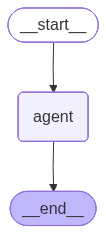

In [66]:

def sf_chat_agent(state: MessagesState) -> dict:
    return {"messages": [llm.invoke(state["messages"])]}

builder_sf = StateGraph(MessagesState)
builder_sf.add_node("agent", sf_chat_agent)
builder_sf.add_edge(START, "agent")
builder_sf.add_edge("agent", END)

sf_short_graph = builder_sf.compile(checkpointer=MemorySaver())

show_graph(sf_short_graph, title="Snowflake Short-Term: ChatSnowflakeCortex + MemorySaver")


In [67]:

cfg_sf_short = {"configurable": {"thread_id": "sf_short_001"}}
for msg in [
    "Hi, I'm Kavya. I work on Cortex Analyst at Snowflake.",
    "My main project is building a natural language BI interface.",
    "What am I working on?",
]:
    r = sf_short_graph.invoke({"messages": [HumanMessage(msg)]}, cfg_sf_short)
    print(f"User : {msg}")
    print(f"Agent: {r['messages'][-1].content[:120]}...\n")


User : Hi, I'm Kavya. I work on Cortex Analyst at Snowflake.
Agent: Nice to meet you, Kavya! I'm glad you're here. So, you work on Cortex Analyst at Snowflake. That's really cool! Cortex A...

User : My main project is building a natural language BI interface.
Agent: That sounds fascinating! Building a natural language BI (Business Intelligence) interface is a challenging but exciting ...

User : What am I working on?
Agent: You're working on building a natural language BI interface as part of Cortex Analyst at Snowflake. You didn't specify th...




### 6.2 — Long-Term Memory with Snowflake Table

Facts auto-extracted → `MERGE INTO` Snowflake → survive process restarts.

```
START ──▶ agent ──▶ END
              │
        ┌─────┴──────────────────────────────┐
        │  1. Load facts from Snowflake table│
        │  2. Call Cortex LLM with context   │
        │  3. Extract new facts via LLM      │
        │  4. MERGE new facts into table     │
        └────────────────────────────────────┘
```

In [68]:

FACT_PROMPT_SF = """Extract memorable facts from the user message.
Return ONLY a JSON array of strings. No markdown. Empty array if nothing memorable."""


#### 📊 Graph: `Snowflake Long-Term: Persistent Semantic Memory`

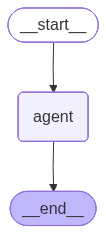

In [69]:

def sf_long_term_agent(state: MessagesState, config: RunnableConfig) -> dict:
    user_id = config["configurable"].get("user_id", "guest")

    # 1. Load semantic memories from Snowflake
    memories = sf_store.search(("memory", user_id, "semantic"))
    mem_text = ""
    if memories:
        mem_text = "\nKnown facts:\n" + \
                   "\n".join(f"  • {m['value'].get('fact','')}" for m in memories)
        print(f"  [SF Store] {len(memories)} memories loaded")

    # 2. Generate response
    messages = [SystemMessage(f"You are a helpful AI assistant.{mem_text}")] + state["messages"]
    response = llm.invoke(messages)

    # 3. Extract & persist new facts
    last_human = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), ""
    )
    if last_human:
        try:
            fact_resp  = llm.invoke([SystemMessage(FACT_PROMPT_SF), HumanMessage(last_human)])
            new_facts  = json.loads(fact_resp.content.strip())
            for fact in (new_facts if isinstance(new_facts, list) else []):
                fid = f"fact_{uuid.uuid4().hex[:8]}"
                sf_store.put(
                    ("memory", user_id, "semantic"), fid,
                    {"fact": fact, "ts": str(datetime.now())}
                )
                print(f"  [SF Store] Persisted: {fact}")
        except Exception:
            pass

    return {"messages": [response]}

# %%
builder_sf_lt = StateGraph(MessagesState)
builder_sf_lt.add_node("agent", sf_long_term_agent)
builder_sf_lt.add_edge(START, "agent")
builder_sf_lt.add_edge("agent", END)

sf_long_graph = builder_sf_lt.compile(checkpointer=MemorySaver())

show_graph(sf_long_graph, title="Snowflake Long-Term: Persistent Semantic Memory")


In [70]:

cfg_sf1 = {"configurable": {"thread_id": "sf_lt_s1", "user_id": "kavya"}}
for msg in [
    "Hi! I'm Kavya. I'm a senior ML engineer focusing on LLMOps.",
    "I use Snowflake Cortex, MLflow, and LangGraph in production.",
    "I'm currently building an evaluation framework for RAG pipelines.",
]:
    r = sf_long_graph.invoke({"messages": [HumanMessage(msg)]}, cfg_sf1)
    print(f"User : {msg}")
    print(f"Agent: {r['messages'][-1].content[:100]}...\n")

# %%
sf_store.show("kavya")

  [SF Store] Persisted: Kavya is a senior ML engineer
  [SF Store] Persisted: Kavya focuses on LLMOps
User : Hi! I'm Kavya. I'm a senior ML engineer focusing on LLMOps.
Agent: Hello Kavya! Nice to meet you. I'm glad to hear that you're working on LLMOps, a very exciting and r...

  [SF Store] 2 memories loaded
  [SF Store] Persisted: Snowflake Cortex
  [SF Store] Persisted: MLflow
  [SF Store] Persisted: LangGraph
User : I use Snowflake Cortex, MLflow, and LangGraph in production.
Agent: That's a great tech stack! Snowflake Cortex is a powerful platform for building and deploying ML mod...

  [SF Store] 5 memories loaded
  [SF Store] Persisted: building an evaluation framework
  [SF Store] Persisted: RAG pipelines
User : I'm currently building an evaluation framework for RAG pipelines.
Agent: Building an evaluation framework for RAG (Retrieval-Augmented Generation) pipelines is a crucial tas...


📦 Snowflake memories for 'kavya' (7 records)
---------------------------------------------

In [71]:

# %%
# Session 2 — memories auto-loaded from Snowflake
cfg_sf2 = {"configurable": {"thread_id": "sf_lt_s2_nextday", "user_id": "kavya"}}
r_new = sf_long_graph.invoke(
    {"messages": [HumanMessage("What do you know about my work?")]}, cfg_sf2
)
print("New session — Agent:\n", r_new["messages"][-1].content)


  [SF Store] 7 memories loaded
New session — Agent:
 You are Kavya, a senior ML engineer who focuses on LLMOps. Your work involves RAG pipelines, building an evaluation framework, LangGraph, MLflow, and Snowflake Cortex. Is that correct?


In [72]:

# %%
# Direct Snowflake verification
print("\n🔍 Direct Snowflake query:")
session.sql("""
    SELECT KEY, VALUE:fact::VARCHAR AS FACT, UPDATED_AT
    FROM   AGENT_MEMORY
    WHERE  NAMESPACE = 'memory/kavya/semantic'
    ORDER  BY UPDATED_AT DESC
""").show()


🔍 Direct Snowflake query:
---------------------------------------------------------------------------------
|"KEY"          |"FACT"                            |"UPDATED_AT"                |
---------------------------------------------------------------------------------
|fact_fe8f1ffe  |RAG pipelines                     |2026-03-17 14:31:09.708000  |
|fact_dcf367a1  |building an evaluation framework  |2026-03-17 14:31:08.154000  |
|fact_68348286  |LangGraph                         |2026-03-17 14:31:02.843000  |
|fact_75fe5cba  |MLflow                            |2026-03-17 14:31:00.963000  |
|fact_f5194d77  |Snowflake Cortex                  |2026-03-17 14:31:00.108000  |
|fact_34ede608  |Kavya focuses on LLMOps           |2026-03-17 14:30:53.039000  |
|fact_920c0fa6  |Kavya is a senior ML engineer     |2026-03-17 14:30:51.861000  |
---------------------------------------------------------------------------------




## 🏁 Memory Decision Tree

```
Need memory?
│
├── This session only?  →  SHORT-TERM
│     ├── Short conversation   →  Full History
│     ├── Long / token-heavy   →  Sliding Window
│     └── Very long + recall   →  Summarization
│
└── Across sessions?    →  LONG-TERM
      ├── User facts / prefs   →  Semantic Memory
      ├── Past interactions    →  Episodic Memory
      └── Agent behavior rules →  Procedural Memory